### Gaurav's Work

Our hypothesis is higher river flow results in higher organic matter and nutrients flowing through the matter. This results in higher pollutants entering whidbey basin, which results in higher algal bloom with higher NDCI data. I used ChatGPT on few of the codes to troubleshoot with variables and to calculate the correlation coefficient. 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("ndci_median.csv")
df.head()

,time,ndci_median
0,2019-01-06,-0.076167
1,2019-01-13,-0.256506
2,2019-01-16,-0.037913
3,2019-02-05,-0.182320
4,2019-02-15,-0.006649


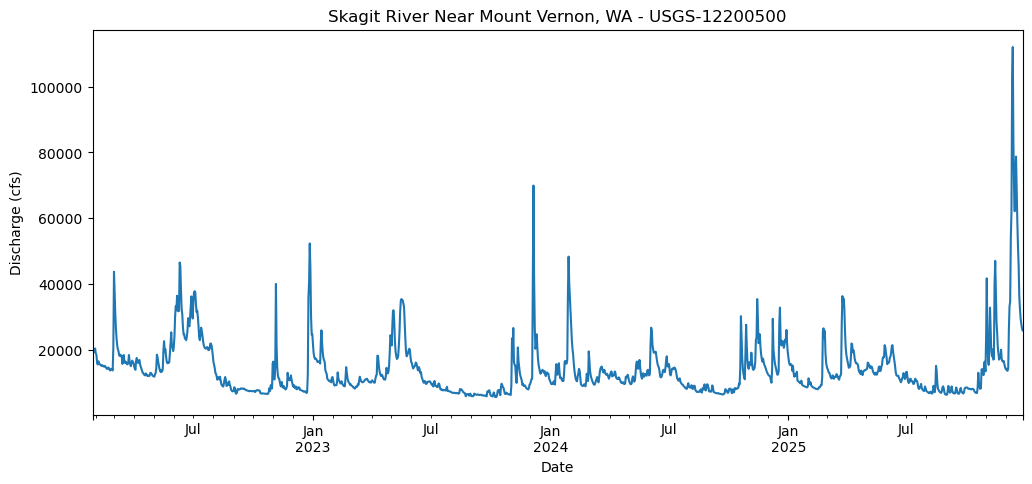

In [13]:
url1 = "https://waterservices.usgs.gov/nwis/dv/?format=rdb&sites=12200500&startDT=2022-01-27&endDT=2025-12-27&parameterCd=00060"

df = pd.read_csv(url1, sep="\t", comment="#")

df = df.iloc[1:].copy()

df.columns = ["agency", "site_no", "datetime", "discharge_cfs", "qualifier"]

df["datetime"] = pd.to_datetime(df["datetime"])
df["discharge_cfs"] = pd.to_numeric(df["discharge_cfs"], errors="coerce")

df = df.set_index("datetime")

plt.figure()
df["discharge_cfs"].plot(figsize = (12,5))
plt.xlabel("Date")
plt.ylabel("Discharge (cfs)")
plt.title("Skagit River Near Mount Vernon, WA - USGS-12200500")
plt.show()

High flow threshold (90th percentile): 23100.00 cfs


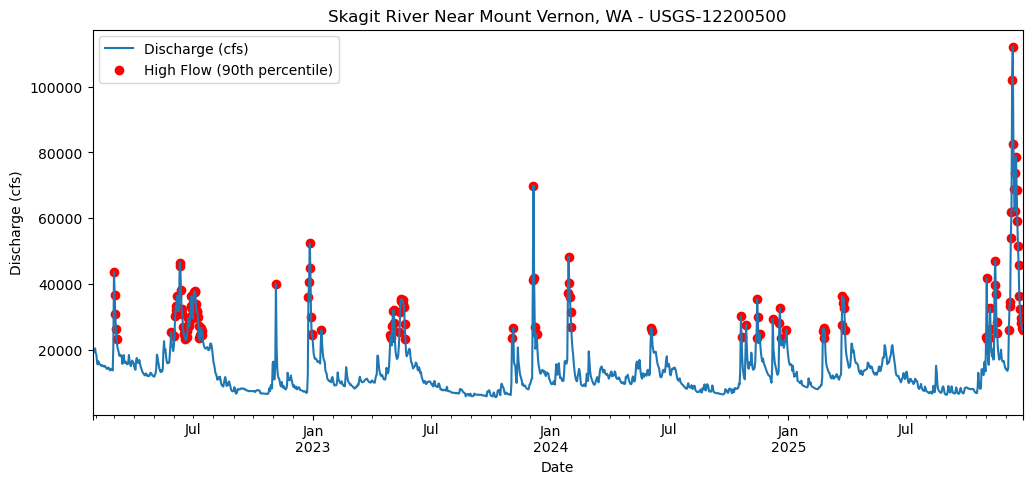

In [14]:
high_flow_threshold = df["discharge_cfs"].quantile(0.9)
df["high_flow"] = df["discharge_cfs"] > high_flow_threshold

print(f"High flow threshold (90th percentile): {high_flow_threshold:.2f} cfs")

# 2️⃣ Plot discharge and mark high flow events
plt.figure(figsize=(12,5))
df["discharge_cfs"].plot(label="Discharge (cfs)")

# Scatter plot for high flows
plt.scatter(df.index[df["high_flow"]],
            df["discharge_cfs"][df["high_flow"]],
            color="red", label="High Flow (90th percentile)")

plt.xlabel("Date")
plt.ylabel("Discharge (cfs)")
plt.title("Skagit River Near Mount Vernon, WA - USGS-12200500")
plt.legend()
plt.show()

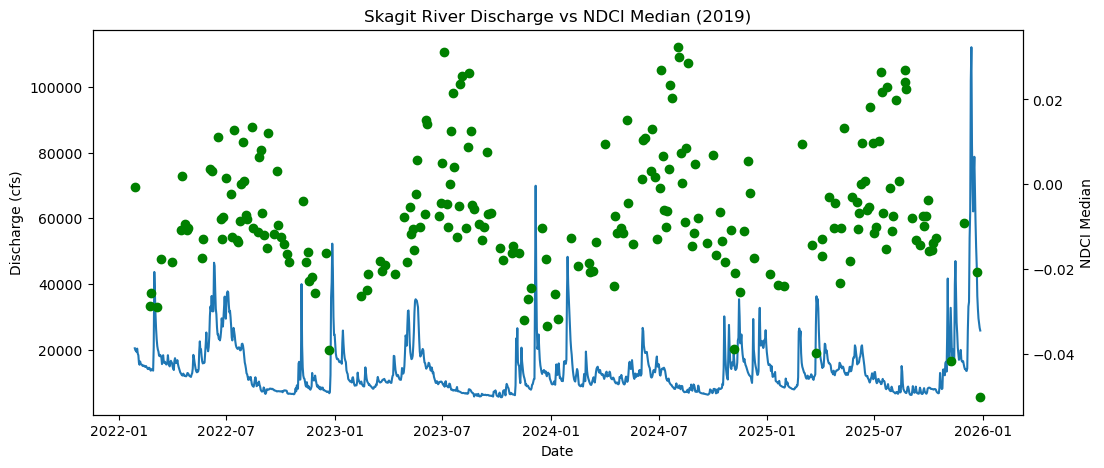

In [15]:
# NDCI data
ndci = pd.read_csv("ndci_median.csv")

ndci["time"] = pd.to_datetime(ndci["time"])
ndci = ndci.set_index("time")
ndci_subset = ndci.loc["2022-01-27":"2025-12-27"]

fig, ax1 = plt.subplots(figsize = (12,5))

# Discharge axis
ax1.plot(df.index, df["discharge_cfs"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Discharge (cfs)")

# NDCI axis
ax2 = ax1.twinx()
ax2.scatter(ndci_subset.index, ndci_subset["ndci_median"], color='green')
ax2.set_ylabel("NDCI Median")

plt.title("Skagit River Discharge vs NDCI Median (2019)")
plt.show()

In [16]:
combined_skagit = df[["discharge_cfs"]].join(ndci[["ndci_median"]], how="inner")
correlation_skagit = combined_skagit["discharge_cfs"].corr(combined_skagit["ndci_median"])
print("Skagit River Correlation:", correlation_skagit)

Skagit River Correlation: -0.1555225377921492


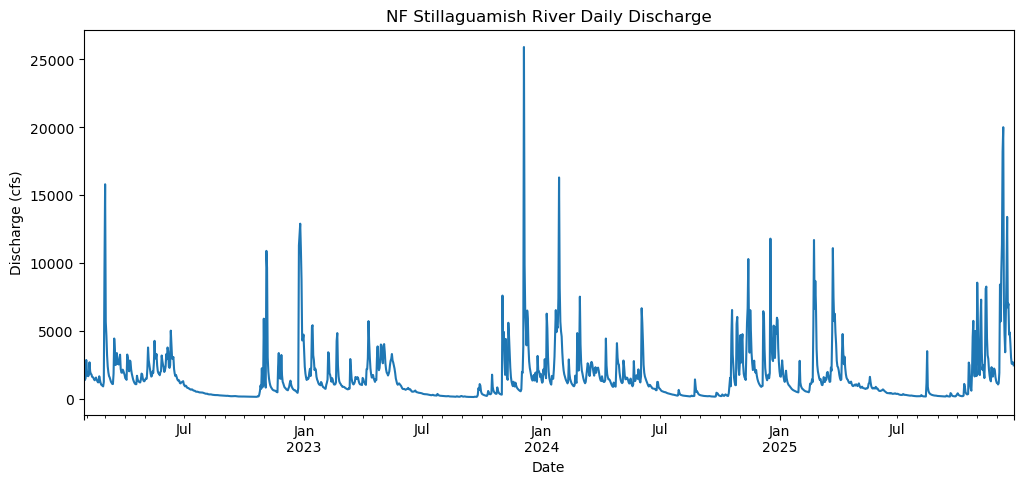

In [17]:
url2 = "https://waterservices.usgs.gov/nwis/dv/?format=rdb&sites=12167000&startDT=2022-01-27&endDT=2025-12-27&parameterCd=00060"

df2 = pd.read_csv(url2, sep="\t", comment="#")
df2 = df2.iloc[1:].copy()

df2.columns = ["agency", "site_no", "datetime", "discharge_cfs", "qualifier"]

df2["datetime"] = pd.to_datetime(df2["datetime"])
df2["discharge_cfs"] = pd.to_numeric(df2["discharge_cfs"], errors="coerce")

df2 = df2.set_index("datetime")

plt.figure(figsize = (12,5))
df2["discharge_cfs"].plot()
plt.xlabel("Date")
plt.ylabel("Discharge (cfs)")
plt.title("NF Stillaguamish River Daily Discharge")
plt.show()

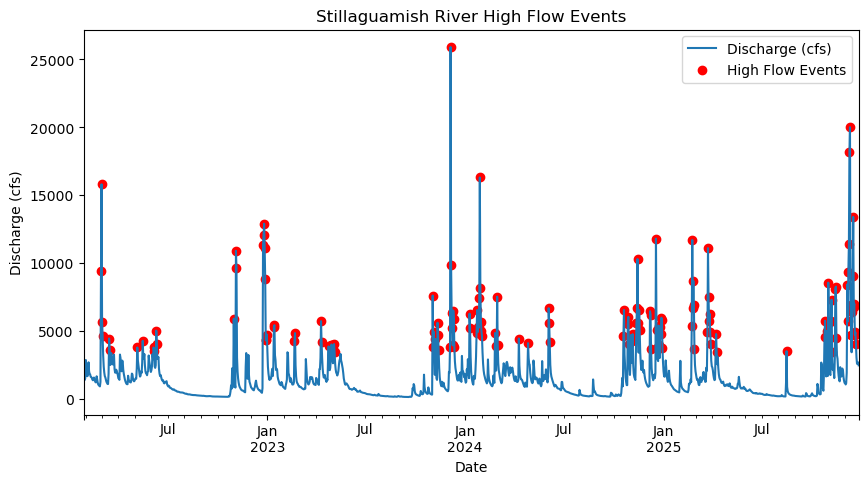

In [18]:
threshold_stilly = df2["discharge_cfs"].quantile(0.9)
df2["high_flow"] = df2["discharge_cfs"] > threshold_stilly

plt.figure(figsize=(10,5))
df2["discharge_cfs"].plot(label="Discharge (cfs)")
plt.scatter(df2.index[df2["high_flow"]],
            df2["discharge_cfs"][df2["high_flow"]],
            color="red",
            label="High Flow Events")
plt.title("Stillaguamish River High Flow Events")
plt.ylabel("Discharge (cfs)")
plt.xlabel("Date")
plt.legend()
plt.show()

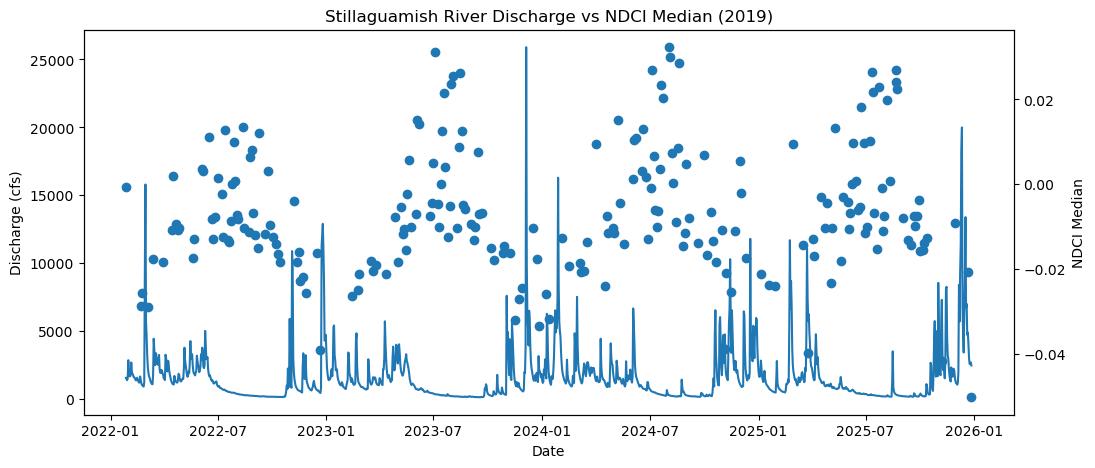

In [19]:
ndci_median = pd.read_csv("ndci_median.csv")

ndci_median["time"] = pd.to_datetime(ndci_median["time"])
ndci_median = ndci_median.set_index("time")

ndci_subset = ndci_median.loc["2022-01-27":"2025-12-27"]

fig, ax1 = plt.subplots(figsize = (12,5))

ax1.plot(df2.index, df2["discharge_cfs"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Discharge (cfs)")

ax2 = ax1.twinx()
ax2.scatter(ndci_subset.index, ndci_subset["ndci_median"])
ax2.set_ylabel("NDCI Median")

plt.title("Stillaguamish River Discharge vs NDCI Median (2019)")
plt.show()

In [43]:
combined_stilly = df2[["discharge_cfs"]].join(ndci[["ndci_median"]], how="inner")
correlation_stilly = combined_stilly["discharge_cfs"].corr(combined_stilly["ndci_median"])
print("Stillaguamish River Correlation:", correlation_stilly)

Stillaguamish River Correlation: -0.38683030437786264


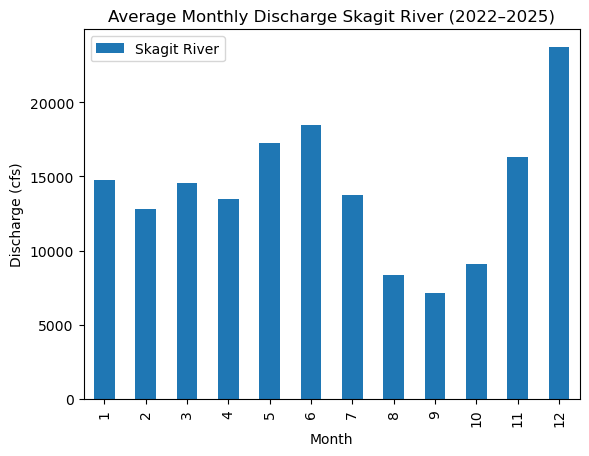

In [21]:
df["month"] = df.index.month
df2["month"] = df2.index.month

skagit_monthly = df.groupby("month")["discharge_cfs"].mean()

monthly_combined = pd.DataFrame({
    "Skagit River": skagit_monthly
})

monthly_combined.plot(kind="bar")

plt.title("Average Monthly Discharge Skagit River (2022–2025)")
plt.ylabel("Discharge (cfs)")
plt.xlabel("Month")
plt.show()

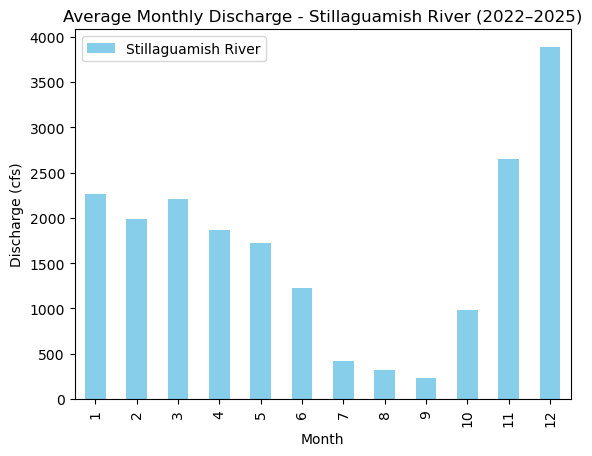

In [20]:
df2.index = pd.to_datetime(df2.index)
df2["month"] = df2.index.month

stilly_monthly = df2.groupby("month")["discharge_cfs"].mean()

monthly_stilly_combined = pd.DataFrame({
    "Stillaguamish River": stilly_monthly
})

monthly_stilly_combined.plot(kind="bar", color="skyblue")  # you can change color
plt.title("Average Monthly Discharge - Stillaguamish River (2022–2025)")
plt.ylabel("Discharge (cfs)")
plt.xlabel("Month")
plt.show()

In [47]:
df1 = pd.read_csv(url1, sep="\t", comment="#")
df1 = df1.iloc[1:].copy()
df1.columns = ["agency", "site_no", "datetime", "discharge_cfs", "qualifier"]

df1["datetime"] = pd.to_datetime(df1["datetime"])
df1["discharge_cfs"] = pd.to_numeric(df1["discharge_cfs"], errors="coerce")
df1 = df1.set_index("datetime")


# Flow dataset from url2
df2 = pd.read_csv(url2, sep="\t", comment="#")
df2 = df2.iloc[1:].copy()
df2.columns = ["agency", "site_no", "datetime", "discharge_cfs", "qualifier"]

df2["datetime"] = pd.to_datetime(df2["datetime"])
df2["discharge_cfs"] = pd.to_numeric(df2["discharge_cfs"], errors="coerce")
df2 = df2.set_index("datetime")


# Align both datasets by datetime
combined = pd.concat([df1["discharge_cfs"], df2["discharge_cfs"]], axis=1)
combined.columns = ["flow_url1", "flow_url2"]
combined = combined.dropna()

# Correlation
correlation = combined["flow_url1"].corr(combined["flow_url2"])
print("Correlation between url1 and url2 flows:", correlation)

Correlation between url1 and url2 flows: 0.6886281290973937


In [16]:
combined = pd.concat(
    [df["discharge_cfs"], ndci_median["ndci_median"]],
    axis=1
)

combined.columns = ["flow", "ndci"]
combined = combined.dropna()

# Test lags (in days)
lags = range(0, 90)

correlations = []

for lag in lags:
    corr = combined["flow"].corr(combined["ndci"].shift(lag))
    correlations.append(corr)

# Find lag with maximum correlation
best_lag = lags[correlations.index(max(correlations))]

print("Lag time (days):", best_lag)
print("Maximum correlation:", max(correlations))

Lag time (days): 38
Maximum correlation: 0.3503947759056964


In [17]:
combined = df[["discharge_cfs"]].join(ndci_subset[["ndci_median"]], how="inner")
flow_threshold = combined["discharge_cfs"].quantile(0.9)
ndci_threshold = combined["ndci_median"].quantile(0.9)
big_flow = combined[combined["discharge_cfs"] >= flow_threshold]
big_ndci = combined[combined["ndci_median"] >= ndci_threshold]
corr_big_flow = big_flow["discharge_cfs"].corr(big_flow["ndci_median"])
print("Correlation during big flow events:", corr_big_flow)
corr_big_ndci = big_ndci["discharge_cfs"].corr(big_ndci["ndci_median"])
print("Correlation during big NDCI events:", corr_big_ndci)
avg_corr = (corr_big_flow + corr_big_ndci) / 2
print("Average correlation for big events:", avg_corr)

Correlation during big flow events: -0.21593258291638917
Correlation during big NDCI events: -0.4435835649480409
Average correlation for big events: -0.329758073932215
